In [1]:
import numpy as np
import matplotlib.pyplot as plt

from astropy.coordinates import EarthLocation,SkyCoord
from astropy.time import Time, TimeDelta
from astropy import units as u
from astropy.coordinates import AltAz

import sys
sys.path.append('../')
from project_dm_smooth_ana import iter_smooth_drdq, smear_drdqz_amp_gauss

In [2]:
# Parameters used to smear the rate
a, b = 1.31662664e+02, 6.33417842e-07

qmax_out = 25000
bins = np.arange(0, qmax_out, 50)  # keV
bc = 0.5 * (bins[:-1] + bins[1:])

qmin, qmax = 1250, 10000

In [3]:
def lst_to_local(sidereal_hours, location):
    """Convert local sidereal times to ref local time"""

    # Reference time to compute sidreal times
    ref_time = Time('2025-01-05 12:00:00', scale='utc')
    lst = ref_time.sidereal_time('apparent', longitude=location.lon)

    ret = []
    sidereal_hours = np.array(sidereal_hours, ndmin=1)
    for _lst_hour in sidereal_hours:
        dt_sec = (_lst_hour - lst.hour) * 3600
        ret.append(ref_time + TimeDelta(dt_sec, format='sec'))

    return ret

In [18]:
# Compute the altitude and azimuth of Cygnus at different local sidereal times
latitude_newhaven  = 41.31 # deg
longitude_newhaven = -72.923611 # deg
elevation_newhaven = 18 # m

lsts = np.linspace(0, 24, 100) # make an array of sidereal times
observing_location = EarthLocation(lat=latitude_newhaven, lon=longitude_newhaven, height=elevation_newhaven)
observing_time = lst_to_local(lsts, observing_location)
aa = AltAz(location=observing_location, obstime=observing_time)

# RA and Dec of Cygnus
coord = SkyCoord(20.62 * 360/24, 42.03, unit=(u.degree, u.degree), frame='icrs')
altazs = coord.transform_to(aa)

alt_deg = altazs.alt.value
az_deg  = altazs.az.value

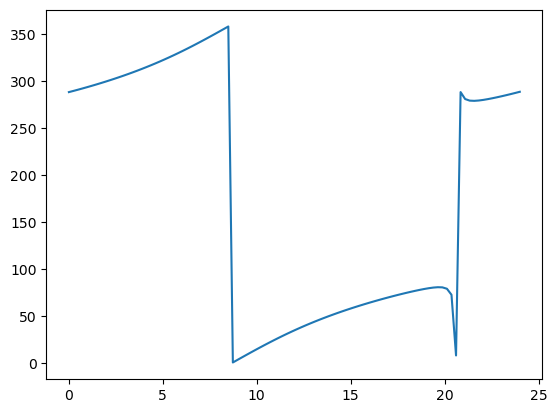

In [19]:
plt.plot(lsts, az_deg)


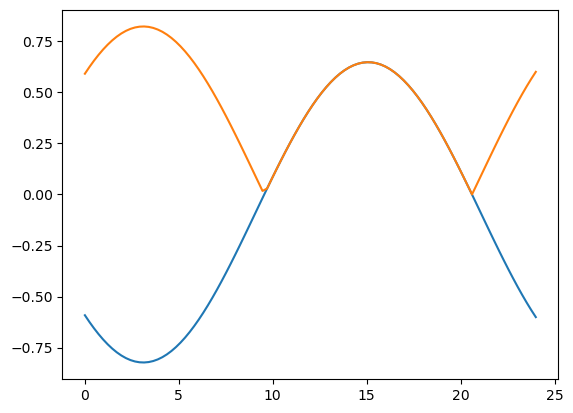

In [20]:
alt_rad, az_rad = np.deg2rad(alt_deg), np.deg2rad(az_deg-100)

plt.plot(lsts, np.cos(alt_rad) * np.cos(az_rad))
plt.plot(lsts, np.abs(np.cos(alt_rad) * np.cos(az_rad)))

#### Now read in the calculated rates and project onto the z axis

In [10]:
def project_drdq(qq, drdq, alt, az, smooth=True):
    if smooth:
        drdq = iter_smooth_drdq(drdq)

    # The momentum transfer is transverse to the DM velocity
    # TODO

    # Project `qq` onto the Azimuth=110 deg direction
    # on the horizon
    # (the approximate orientation of the z axis)
    alt_rad, phi_rad = np.deg2rad(alt), np.deg2rad(az+180-110)
    qqz = np.abs(qq * np.cos(alt_rad) * np.cos(phi_rad))
    drdqz = drdq

    return qqz, drdqz

def calc_rate(qq, drdqz, qmin, qmax):
    good_idx = np.logical_and(qq > qmin, qq < qmax)
    good_idx = np.logical_and(good_idx, drdqz > 1e-10)

    # Events/hour
    return np.trapz(drdqz[good_idx], qq[good_idx]) * 3600

def load_drdq(mx, alpha, mphi):

    # data_dir = f'/home/yt388/project/data/dm_rate/mphi_{mphi:.0e}'
    # data_dir = r'/home/yt388/microspheres/dm_nanospheres/analysis_notebooks/'
    data_dir = '/Users/yuhan/work/nanospheres/dm_nanospheres/analysis_notebooks'

    R_um = 0.083
    prefix = '_100mevthr'
    file = f'{data_dir}/drdq{prefix}_nanosphere_{R_um:.2e}_{mx:.5e}_{alpha:.5e}_{mphi:.0e}.npz'

    drdq_npz = np.load(file)
    qq = drdq_npz['q_kev']
    drdq = drdq_npz['drdq_hz_kev']

    return qq, drdq

def get_dm_rate_interp(mphi, mx, alpha, mx_list, alpha_list):
    i_mx = np.argmin(np.abs(mx_list - mx))

    # First index larger than alpha
    j_alpha = np.nonzero(alpha_list > alpha)[0][0]
    i_alpha = j_alpha - 1
    d_alpha = alpha_list[j_alpha] - alpha_list[i_alpha]

    _qq_i, _drdq_i = load_drdq(mx_list[i_mx], alpha_list[i_alpha], mphi)
    _qq_j, _drdq_j = load_drdq(mx_list[i_mx], alpha_list[j_alpha], mphi)

    qq = np.linspace(50, 10000, 200)
    drdq_i = np.interp(qq, _qq_i, _drdq_i)
    drdq_j = np.interp(qq, _qq_j, _drdq_j)

    # Interpolate between the two rates to the input alpha
    ret = drdq_i + (alpha - alpha_list[i_alpha]) * (drdq_j - drdq_i) / d_alpha

    return qq, ret

In [11]:
mx_list_coarse = np.logspace(-1, 4, 77)
alpha_list_coarse = np.logspace(-7, -3, 79)

R_um = 0.083
mphi = 1
mx_1, alpha_1 = 2.4075701346762397, 4.453577560919782e-07
qq, drdq = get_dm_rate_interp(mphi, mx_1, alpha_1, mx_list_coarse, alpha_list_coarse)

# # mx = mx_list_coarse[30]
# # alpha = alpha_list_coarse[26]
# mx = mx_list_coarse[21]
# alpha = alpha_list_coarse[12]
# print(f'M_chi = {mx:.2f} GeV, alpha_n = {alpha:2e}')

# data_dir = f'/home/yt388/project/data/dm_rate/mphi_{mphi:.0e}'
# # data_dir = '/Users/yuhan/work/nanospheres/dm_nanospheres/analysis_notebooks'
# prefix = '_100mevthr'
# file = f'{data_dir}/drdq{prefix}_nanosphere_{R_um:.2e}_{mx:.5e}_{alpha:.5e}_{mphi:.0e}.npz'

# drdq_npz = np.load(file)
# qq = drdq_npz['q_kev']
# drdq = drdq_npz['drdq_hz_kev']

5.76697219335602


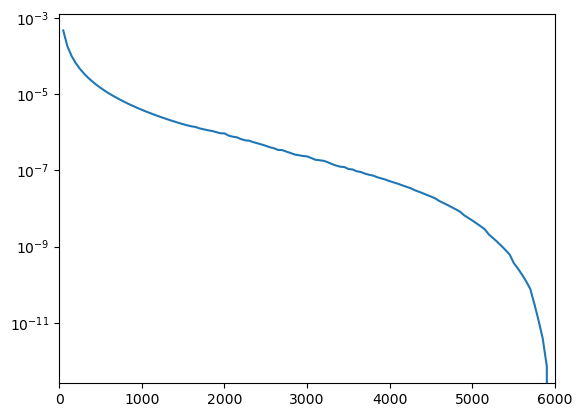

In [12]:
plt.plot(qq, iter_smooth_drdq(drdq))
plt.xlim(0, 6000)
plt.yscale('log')
print(calc_rate(qq, iter_smooth_drdq(drdq), qmin, qmax))


In [15]:
drdq = iter_smooth_drdq(drdq)

drdqzs_smeared = []
drdqzs = []
for i, alt in enumerate(alt_deg):
    # print(i)
    az = az_deg[i]

    _qqz, _drdqz = project_drdq(qq, drdq, alt, az, smooth=False)
    _qqz, _drdqz_smeared = smear_drdqz_amp_gauss(_qqz, _drdqz, a, b)
    drdqz_smeared_resampled = np.interp(bc, _qqz, _drdqz_smeared, right=0)

    # qqzs.append(bc)
    drdqzs_smeared.append(_drdqz_smeared)
    drdqzs.append(drdqz_smeared_resampled)

Text(0, 0.5, '$dR / dq_z$ (Events/keV/s)')

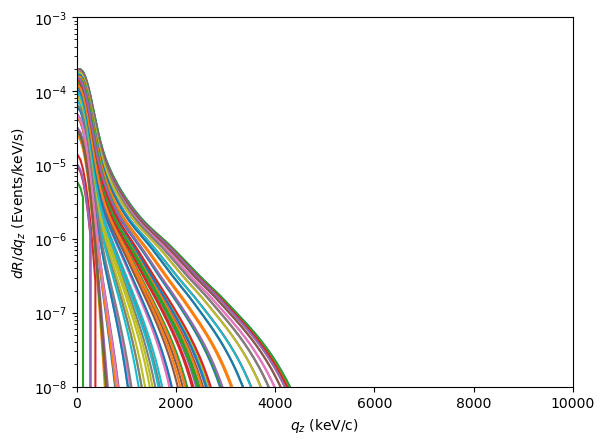

In [16]:
rates = []
for i in range(alt_deg.size):
    # if i >20
    rates.append(calc_rate(bc, drdqzs[i], qmin, qmax))
    plt.plot(bc, drdqzs[i])

plt.yscale('log')
plt.ylim(1e-8, 1e-3)
plt.xlim(0, 10000)

plt.xlabel('$q_z$ (keV/c)')
plt.ylabel('$dR / dq_z$ (Events/keV/s)')

ValueError: x and y must have same first dimension, but have shapes (100,) and (75,)

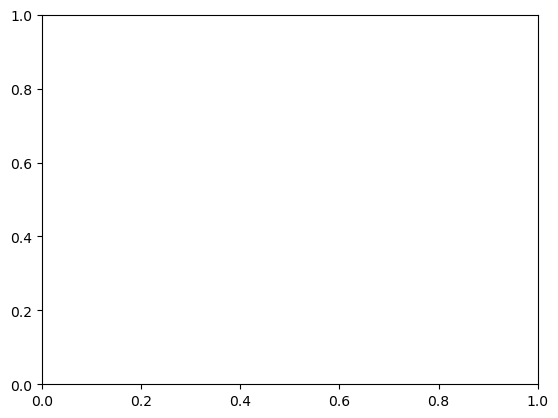

In [21]:
plt.plot(lsts, rates)

plt.xlim(0, 24)
plt.ylim(0, 15)

plt.xlabel('Sidereal time (h)')
plt.ylabel('Rate (Events/h)')

np.savez('rate_sidereal_hour.npz', lst=lsts, rate_events_h=rates)